C:\Users\Hela\AppData\Local\Temp\ipykernel_2980\1043580578.py:30: RuntimeWarning: overflow encountered in scalar negative
  gr = np.exp(-((neighbor - center)**2) / (2 * sigma_r**2))
C:\Users\Hela\AppData\Local\Temp\ipykernel_2980\1043580578.py:30: RuntimeWarning: overflow encountered in scalar subtract
  gr = np.exp(-((neighbor - center)**2) / (2 * sigma_r**2))


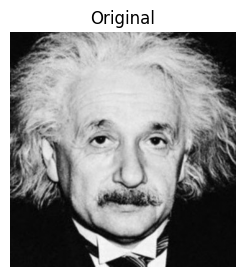

In [16]:
#part a)
import cv2
import numpy as np
import matplotlib.pyplot as plt

def bilateral_filter(gray, kernel_size, sigma_s, sigma_r):
    h, w = gray.shape
    pad = kernel_size // 2

    padded = np.pad(gray, pad, mode='reflect')
    output = np.zeros_like(gray, dtype=np.float32)

    for i in range(h):
        for j in range(w):

            wp_total = 0
            filtered_pixel = 0

            center = padded[i + pad, j + pad]

            for x in range(-pad, pad+1):
                for y in range(-pad, pad+1):

                    neighbor = padded[i + pad + x, j + pad + y]

                    # Spatial Gaussian
                    gs = np.exp(-(x**2 + y**2) / (2 * sigma_s**2))

                    # Range Gaussian
                    gr = np.exp(-((neighbor - center)**2) / (2 * sigma_r**2))

                    w_p = gs * gr

                    filtered_pixel += neighbor * w_p
                    wp_total += w_p

            output[i, j] = filtered_pixel / wp_total

    return output.astype(np.uint8)


# Load Image
img = cv2.imread('einstein.png', cv2.IMREAD_GRAYSCALE)

# Apply bilateral filter
filtered = bilateral_filter(img, kernel_size=8, sigma_s=5, sigma_r=20)

# Show results
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')



plt.show()

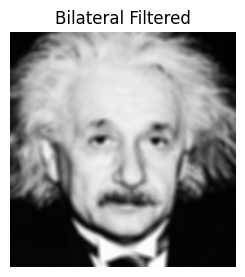

In [17]:
plt.subplot(1,2,2)
plt.imshow(filtered, cmap='gray')
plt.title("Bilateral Filtered")
plt.axis('off')
plt.show()

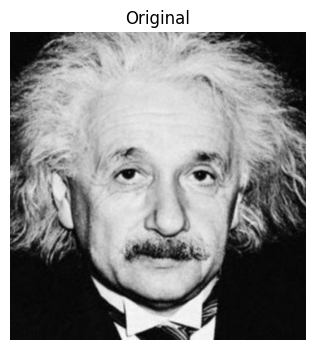

In [18]:
#part b)
import cv2
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('einstein.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Apply Gaussian smoothing
blurred = cv2.GaussianBlur(img, (5, 5), 1)

# Show results
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis('off')



plt.show()

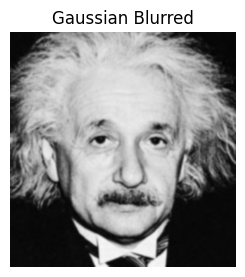

In [19]:
plt.subplot(1,2,2)
plt.imshow(blurred)
plt.title("Gaussian Blurred")
plt.axis('off')

plt.show()

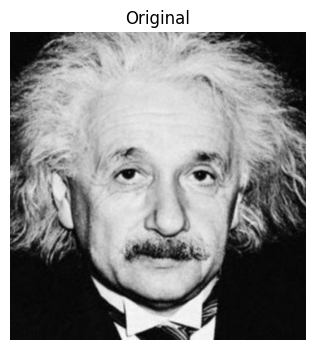

In [20]:
#part c)
import cv2
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('einstein.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Apply bilateral filter
bilateral = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

# Show results
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis('off')



plt.show()

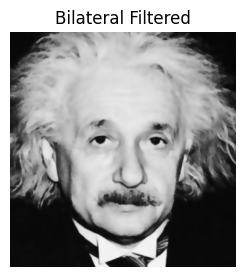

In [21]:
plt.subplot(1,2,2)
plt.imshow(bilateral)
plt.title("Bilateral Filtered")
plt.axis('off')
plt.show()